# Load the Data

In [ ]:
from google.colab import drive
from shutil import copy2
import duckdb
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats
import plotly.express as px
from pylab import rcParams
import pandas as pd

darkmodel = False
rcParams['figure.figsize'] = (12,6)
pd.options.display.float_format = '{:,.2f}'.format

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

if darkmodel:
    # 1. Define a sophisticated E-commerce color palette
    # These colors are chosen for high contrast against the #212946 background
    colors = [
        "#08F7FE",  # Cyan Glow
        "#FE53BB",  # Neon Pink
        "#F5D300",  # Cyber Yellow
        "#00ff41",  # Matrix Green
        "#9467bd",  # Royal Purple
    ]

    # 2. Enhanced Dictionary with Complex Styling
    refined_dark_style = {
        # Background and Canvas
        "figure.facecolor": "#212946",
        "axes.facecolor": "#212946",
        "savefig.facecolor": "#212946",

        # Grid Sophistication
        "axes.grid": True,
        "axes.grid.which": "both",
        "grid.color": "#2A3459",
        "grid.linewidth": "1",
        "grid.alpha": 0.5,

        # Typography & Labels (Optimized for readability)
        "text.color": "#E2E2E2",
        "axes.labelcolor": "#E2E2E2",
        "axes.labelsize": 14,
        "axes.titlesize": 18,
        "axes.titleweight": "bold",
        "axes.titlepad": 20,
        "xtick.color": "#8E9CC3",
        "ytick.color": "#8E9CC3",
        "font.size": 12,

        # Spines (Clean aesthetic)
        "axes.spines.left": False,
        "axes.spines.right": False,
        "axes.spines.top": False,
        "axes.spines.bottom": True,
        "axes.edgecolor": "#2A3459",

        # Line & Marker Settings
        "lines.linewidth": 2.5,
        "lines.markersize": 8,
        "axes.prop_cycle": plt.cycler(color=colors),
    }

    plt.rcParams.update(refined_dark_style)

else:
    # 1. Defining the "Paper & Ink" Palette
    # Deep Blue #003366 | Oxide Red #A52A2A
    ecom_vintage_colors = [
        "#003366",  # Oxford Blue (Primary)
        "#A52A2A",  # Oxide Red (Comparison)
        "#006400",  # Dark Green (Success Metrics)
        "#704214",  # Sepia (Neutral)
    ]

    vintage_style = {
        # Background - The specific parchment hex you requested
        "figure.facecolor": "#f7e4b7",
        "axes.facecolor": "#f7e4b7",
        "savefig.facecolor": "#f7e4b7",

        # Grid - Subtle contrast using a darker version of the background
        "axes.grid": True,
        "grid.color": "#e2d1a8",
        "grid.linestyle": "-",
        "grid.linewidth": 1.0,

        # Typography - Deep Charcoal/Blue instead of pure black for a softer feel
        "text.color": "#2C2C2C",
        "axes.labelcolor": "#2C2C2C",
        "xtick.color": "#5D5D5D",
        "ytick.color": "#5D5D5D",
        "axes.titlesize": 16,
        "axes.titleweight": "bold",
        "axes.titlepad": 15,
        "font.size": 11,

        # Spines - Classic 'L-frame' for publication
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": True,
        "axes.spines.bottom": True,
        "axes.edgecolor": "#2C2C2C",
        "axes.linewidth": 1.5,

        # Data Point Styling
        "axes.prop_cycle": plt.cycler(color=ecom_vintage_colors),
        "lines.linewidth": 2.2,
        "lines.markersize": 8,
        "patch.edgecolor": "#f7e4b7", # Borders on bars/pie slices
    }

    plt.rcParams.update(vintage_style)

In [ ]:
drive.mount('/content/drive')
SourceDB = '/content/drive/My Drive/Colab Notebooks/InstaCart.db'
Dest = os.path.join(os.getcwd(), 'InstaCart')
os.makedirs(Dest, exist_ok=True)
copy2(SourceDB, Dest)

os.chdir(Dest)

Mounted at /content/drive


In [ ]:
IC = duckdb.connect(database='InstaCart.db')
tables = IC.execute("SHOW TABLES;").fetchdf()
#tables = IC.execute("PRAGMA show_tables;").fetchdf()
print("Tables in InstaCart.db:")
display(tables)

Tables in InstaCart.db:


,name
0,AISLE
1,DepartmentData
2,FullTrainData
3,OrderTest
4,OrderTrain
5,OrdersDetails
6,ProductsData


In [ ]:
Query01 = 'SELECT * FROM FullTrainData ORDER BY Order_ID ASC, user_id ASC;'
TrainData = IC.execute(Query01).fetchdf()
display(TrainData.sample(8))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,order_id,user_id,product_id,aisle_id,department_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered
900010,2221660,90523,13874,17,13,6,4,13,29.00,16,0
981412,2421101,122667,24852,24,4,15,4,10,30.00,4,1
816490,2014742,111270,10621,83,4,31,0,20,7.00,22,1
1190986,2942115,202425,26221,37,1,4,6,17,9.00,6,0
1107981,2738734,30757,8596,90,7,16,0,12,6.00,3,0
1077071,2662727,166561,38985,92,18,33,1,00,5.00,15,1
40548,99283,143298,45066,24,4,4,0,13,17.00,2,1
588586,1447661,188037,41834,30,6,31,1,19,8.00,10,1


## Data Glossary

| Column | Data Type | Description |
| --- | --- | --- |
| order_id               | category  | Unique identifier for each order|
| user_id                | category  | Unique identifier for each user/customer|
| product_id             | category  | Unique identifier for each product|
| aisle_id               | category  | Unique identifier for product aisle location in store|
| department_id          | category  | Unique identifier for product department category|
| order_number           | int64     | Sequential order number for each user (1 = first order, higher = later)|
| order_dow              | int64     | Day of week order placed (0=Saturday, 1=Sunday, ..., 6=Friday)|
| order_hour_of_day      | category  | Hour of day when order placed (0-23)|
| days_since_prior_order | float64   | Days elapsed since user's previous order (NaN for first order)|
| add_to_cart_order      | int64     | Sequential position in cart when product added (1=first added)|
| reordered              | int64     | 1 if previously ordered by user, 0 otherwise|

# Simple Data Statistics Summary

In [ ]:
CatColumn = ['order_id', 'user_id', 'product_id', 'aisle_id', 'department_id', 'order_hour_of_day']
TrainData[CatColumn] = TrainData[CatColumn].astype('category')
TrainData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1384617 entries, 0 to 1384616
Data columns (total 11 columns):
 #   Column                  Non-Null Count    Dtype   
---  ------                  --------------    -----   
 0   order_id                1384617 non-null  category
 1   user_id                 1384617 non-null  category
 2   product_id              1384617 non-null  category
 3   aisle_id                1384617 non-null  category
 4   department_id           1384617 non-null  category
 5   order_number            1384617 non-null  int64   
 6   order_dow               1384617 non-null  int64   
 7   order_hour_of_day       1384617 non-null  category
 8   days_since_prior_order  1384617 non-null  float64 
 9   add_to_cart_order       1384617 non-null  int64   
 10  reordered               1384617 non-null  int64   
dtypes: category(6), float64(1), int64(4)
memory usage: 85.3 MB


In [ ]:
TrainData.describe()

,order_number,order_dow,days_since_prior_order,add_to_cart_order,reordered
count,"1,384,617.00","1,384,617.00","1,384,617.00","1,384,617.00","1,384,617.00"
mean,17.09,2.70,17.07,8.76,0.60
std,16.61,2.17,10.43,7.42,0.49
min,4.00,0.00,0.00,1.00,0.00
25%,6.00,1.00,7.00,3.00,0.00
50%,11.00,3.00,15.00,7.00,1.00
75%,21.00,5.00,30.00,12.00,1.00
max,100.00,6.00,30.00,80.00,1.00


In [ ]:
TrainData.describe(include = 'category')

,order_id,user_id,product_id,aisle_id,department_id,order_hour_of_day
count,1384617,1384617,1384617,1384617,1384617,1384617
unique,131209,131209,39123,134,21,24
top,2813632,149753,24852,83,4,14
freq,80,80,18726,150609,409087,119370


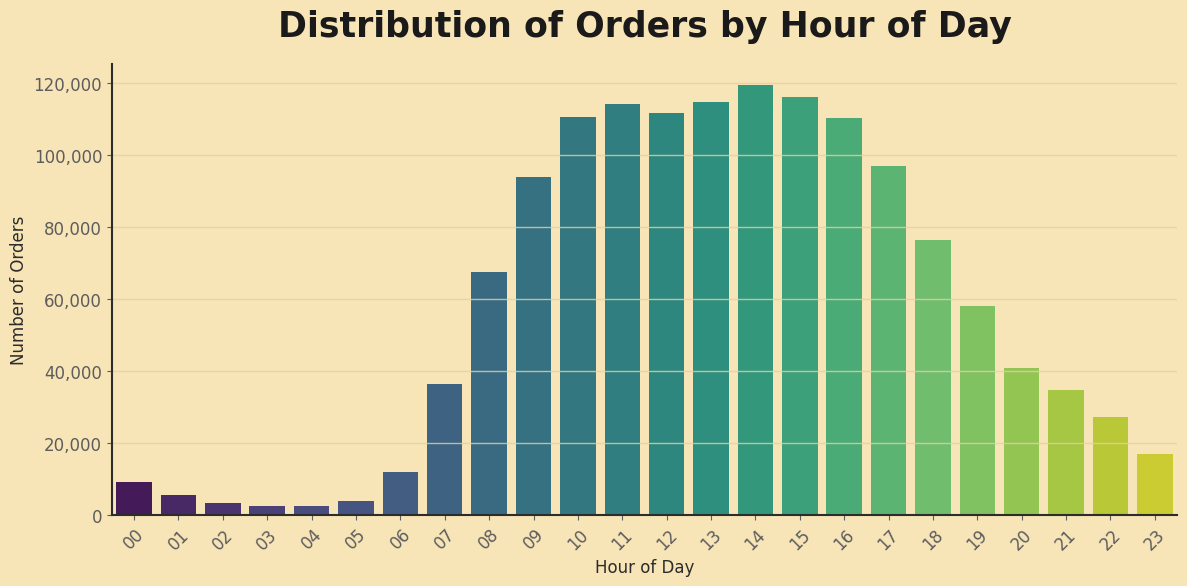

In [ ]:
hour_counts = TrainData['order_hour_of_day'].value_counts().reset_index()
hour_counts.columns = ['order_hour_of_day', 'count']
hour_counts = hour_counts.sort_values('order_hour_of_day')

plt.figure(figsize=(12, 6))
ax = sns.barplot(x='order_hour_of_day',
                 y='count',
                 data=hour_counts,
                 palette='viridis',
                 hue='order_hour_of_day',
                 legend=False,
                )
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax.tick_params(axis='both', which='major', labelsize=12)
plt.title('Distribution of Orders by Hour of Day', fontsize=25, pad=20)
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
def MissingVals(Data):
    report = pd.DataFrame({
        'Missing Values': Data.isnull().sum(),
        'Percentage': (Data.isnull().sum() / len(Data)) * 100
    }).sort_values('Percentage', ascending=False)
    return report

display(MissingVals(TrainData))

,Missing Values,Percentage
order_id,0,0.00
user_id,0,0.00
product_id,0,0.00
aisle_id,0,0.00
department_id,0,0.00
order_number,0,0.00
order_dow,0,0.00
order_hour_of_day,0,0.00
days_since_prior_order,0,0.00
add_to_cart_order,0,0.00


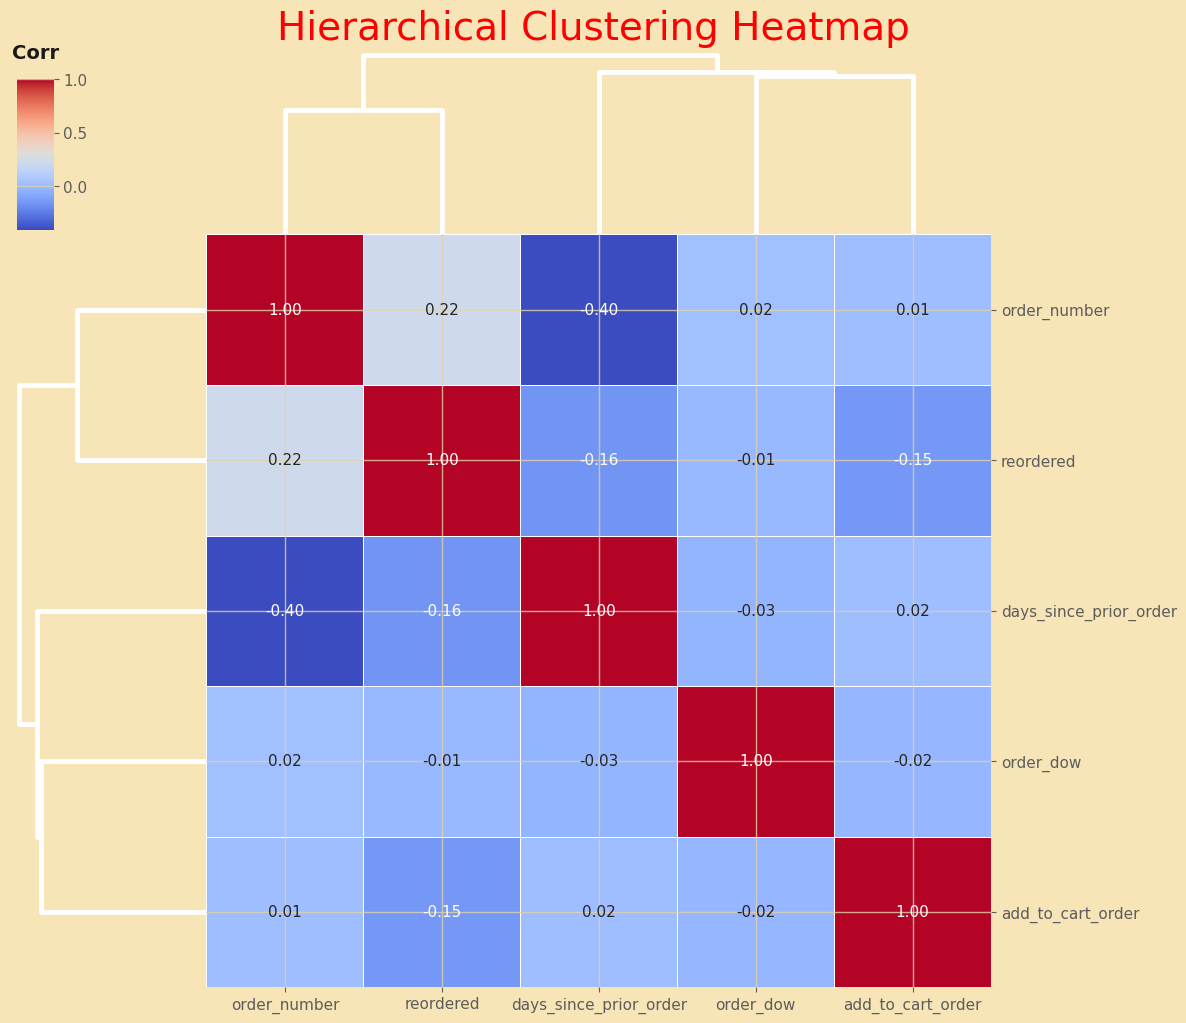

In [ ]:
Corelation = TrainData.select_dtypes(include=['number']).corr()
g = sns.clustermap(
    Corelation,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=.5,
    figsize=(12, 10),
    cbar_pos=(0.02, 0.8, 0.03, 0.15)
)
for ax in [g.ax_row_dendrogram, g.ax_col_dendrogram]:
    for line in ax.collections:
        line.set_linewidth(3.5)
        line.set_color('white')
g.fig.suptitle('Hierarchical Clustering Heatmap', fontsize=28, color='red', y=1.02)
g.ax_cbar.set_title('Corr', fontsize=14)
plt.show()

In [ ]:
def Interactive_Correlation(Data : pd.DataFrame,
                            method : str ='pearson'):
    """
    Generates an interactive correlation heatmap.
    Arguments:
        Data: The DataFrame to analyze (e.g., TrainData).
        method: 'pearson', 'spearman', or 'kendall'.
    """
    Corrs = Data.select_dtypes(include=['number']).corr(method=method)
    fig = px.imshow(Corrs,
                    text_auto=".2f",
                    aspect="auto",
                    color_continuous_scale='RdBu_r',
                    zmin=-1,
                    zmax=1,
                    title=f"Interactive Correlation Matrix ({method.capitalize()})",
                    labels=dict(color="Correlation"),
                   )
    fig.update_layout(width=800,
                      height=800,
                      xaxis_nticks=36,
                      template='plotly_dark',
                      title_font_size=28,
                      title_font_color='red',
                     )
    return fig.show()

In [ ]:
Interactive_Correlation(TrainData, method='pearson')

In [ ]:
# Spearman - Measures monotonic relationship (Rank-based)
# BEST for 'add_to_cart_order' and 'order_number'
Interactive_Correlation(TrainData, method='spearman')

# Univariate Analysis

In [ ]:
def Identify_Columns(Data):
    numerical_cols = Data.select_dtypes(include=['int64', 'float64']).columns.tolist()
    print("Numerical columns:", numerical_cols)
    return numerical_cols

def Univariate_Statistics(Data, col):
    iqr = Data[col].quantile(0.75) - Data[col].quantile(0.25)
    stats_dict = {
        'count': [Data[col].count()],
        'mean': [Data[col].mean()],
        'median': [Data[col].median()],
        'std': [Data[col].std()],
        'min': [Data[col].min()],
        'max': [Data[col].max()],
        'q25': [Data[col].quantile(0.25)],
        'q75': [Data[col].quantile(0.75)],
        'iqr': [iqr],
        'upper_whisker': [Data[col].quantile(0.75) + 1.5 * iqr],
        'lower_whisker': [Data[col].quantile(0.25) - 1.5 * iqr],
        'skewness': [stats.skew(Data[col].dropna())],
        'kurtosis': [stats.kurtosis(Data[col].dropna())],
        'missing': [Data[col].isnull().sum()],
    }
    return pd.DataFrame(stats_dict)

In [ ]:
Numerics = Identify_Columns(TrainData)
all_stats = list()
for col in Numerics:
    stats_df = Univariate_Statistics(TrainData, col)
    stats_df.index = [col]
    all_stats.append(stats_df)

StatSum = pd.concat(all_stats)
display(StatSum)

Numerical columns: ['order_number', 'order_dow', 'days_since_prior_order', 'add_to_cart_order', 'reordered']


,count,mean,median,std,min,max,q25,q75,iqr,upper_whisker,lower_whisker,skewness,kurtosis,missing
order_number,1384617,17.09,11.00,16.61,4.00,100.00,6.00,21.00,15.00,43.50,-16.50,2.24,5.90,0
order_dow,1384617,2.70,3.00,2.17,0.00,6.00,1.00,5.00,4.00,11.00,-5.00,0.18,-1.40,0
days_since_prior_order,1384617,17.07,15.00,10.43,0.00,30.00,7.00,30.00,23.00,64.50,-27.50,0.07,-1.57,0
add_to_cart_order,1384617,8.76,7.00,7.42,1.00,80.00,3.00,12.00,9.00,25.50,-10.50,1.69,4.17,0
reordered,1384617,0.60,1.00,0.49,0.00,1.00,0.00,1.00,1.00,2.50,-1.50,-0.40,-1.84,0


In [ ]:
def Visualized_Univariate(Data:pd.DataFrame,
                          NumCols:list,
                          save:bool=False,
                         ):
    n_cols = len(NumCols)
    fig, axes = plt.subplots(n_cols, 2, figsize=(15, 4 * n_cols))
    axes = axes.ravel()

    for i, col in enumerate(NumCols):
        # Histogram
        axes[i*2].hist(Data[col].dropna(), bins=30, alpha=0.7, edgecolor='black')
        axes[i*2].set_title(f'Histogram - {col}')
        axes[i*2].set_xlabel(col)
        axes[i*2].set_ylabel('Frequency')

        # Boxplot
        axes[i*2+1].boxplot(Data[col].dropna())
        axes[i*2+1].set_title(f'Boxplot - {col}')
        axes[i*2+1].set_ylabel(col)

    plt.tight_layout()
    if save:
        plt.savefig('univariate_analysis_all.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Individual KDE plots for continuous variables
    print('\n\n')
    continuous_cols = ['days_since_prior_order', 'order_number', 'add_to_cart_order']
    for col in continuous_cols:
        if col in NumCols:
            plt.figure(figsize=(10, 4))
            plt.subplot(1, 2, 1)
            sns.histplot(Data[col], kde=True, bins=30)
            plt.title(f'Distribution - {col}')

            plt.subplot(1, 2, 2)
            sns.boxplot(y=Data[col])
            plt.title(f'Boxplot - {col}')

            plt.tight_layout()
            if save:
                plt.savefig(f'univariate_{col}.png', dpi=300, bbox_inches='tight')
            plt.show()
    return True

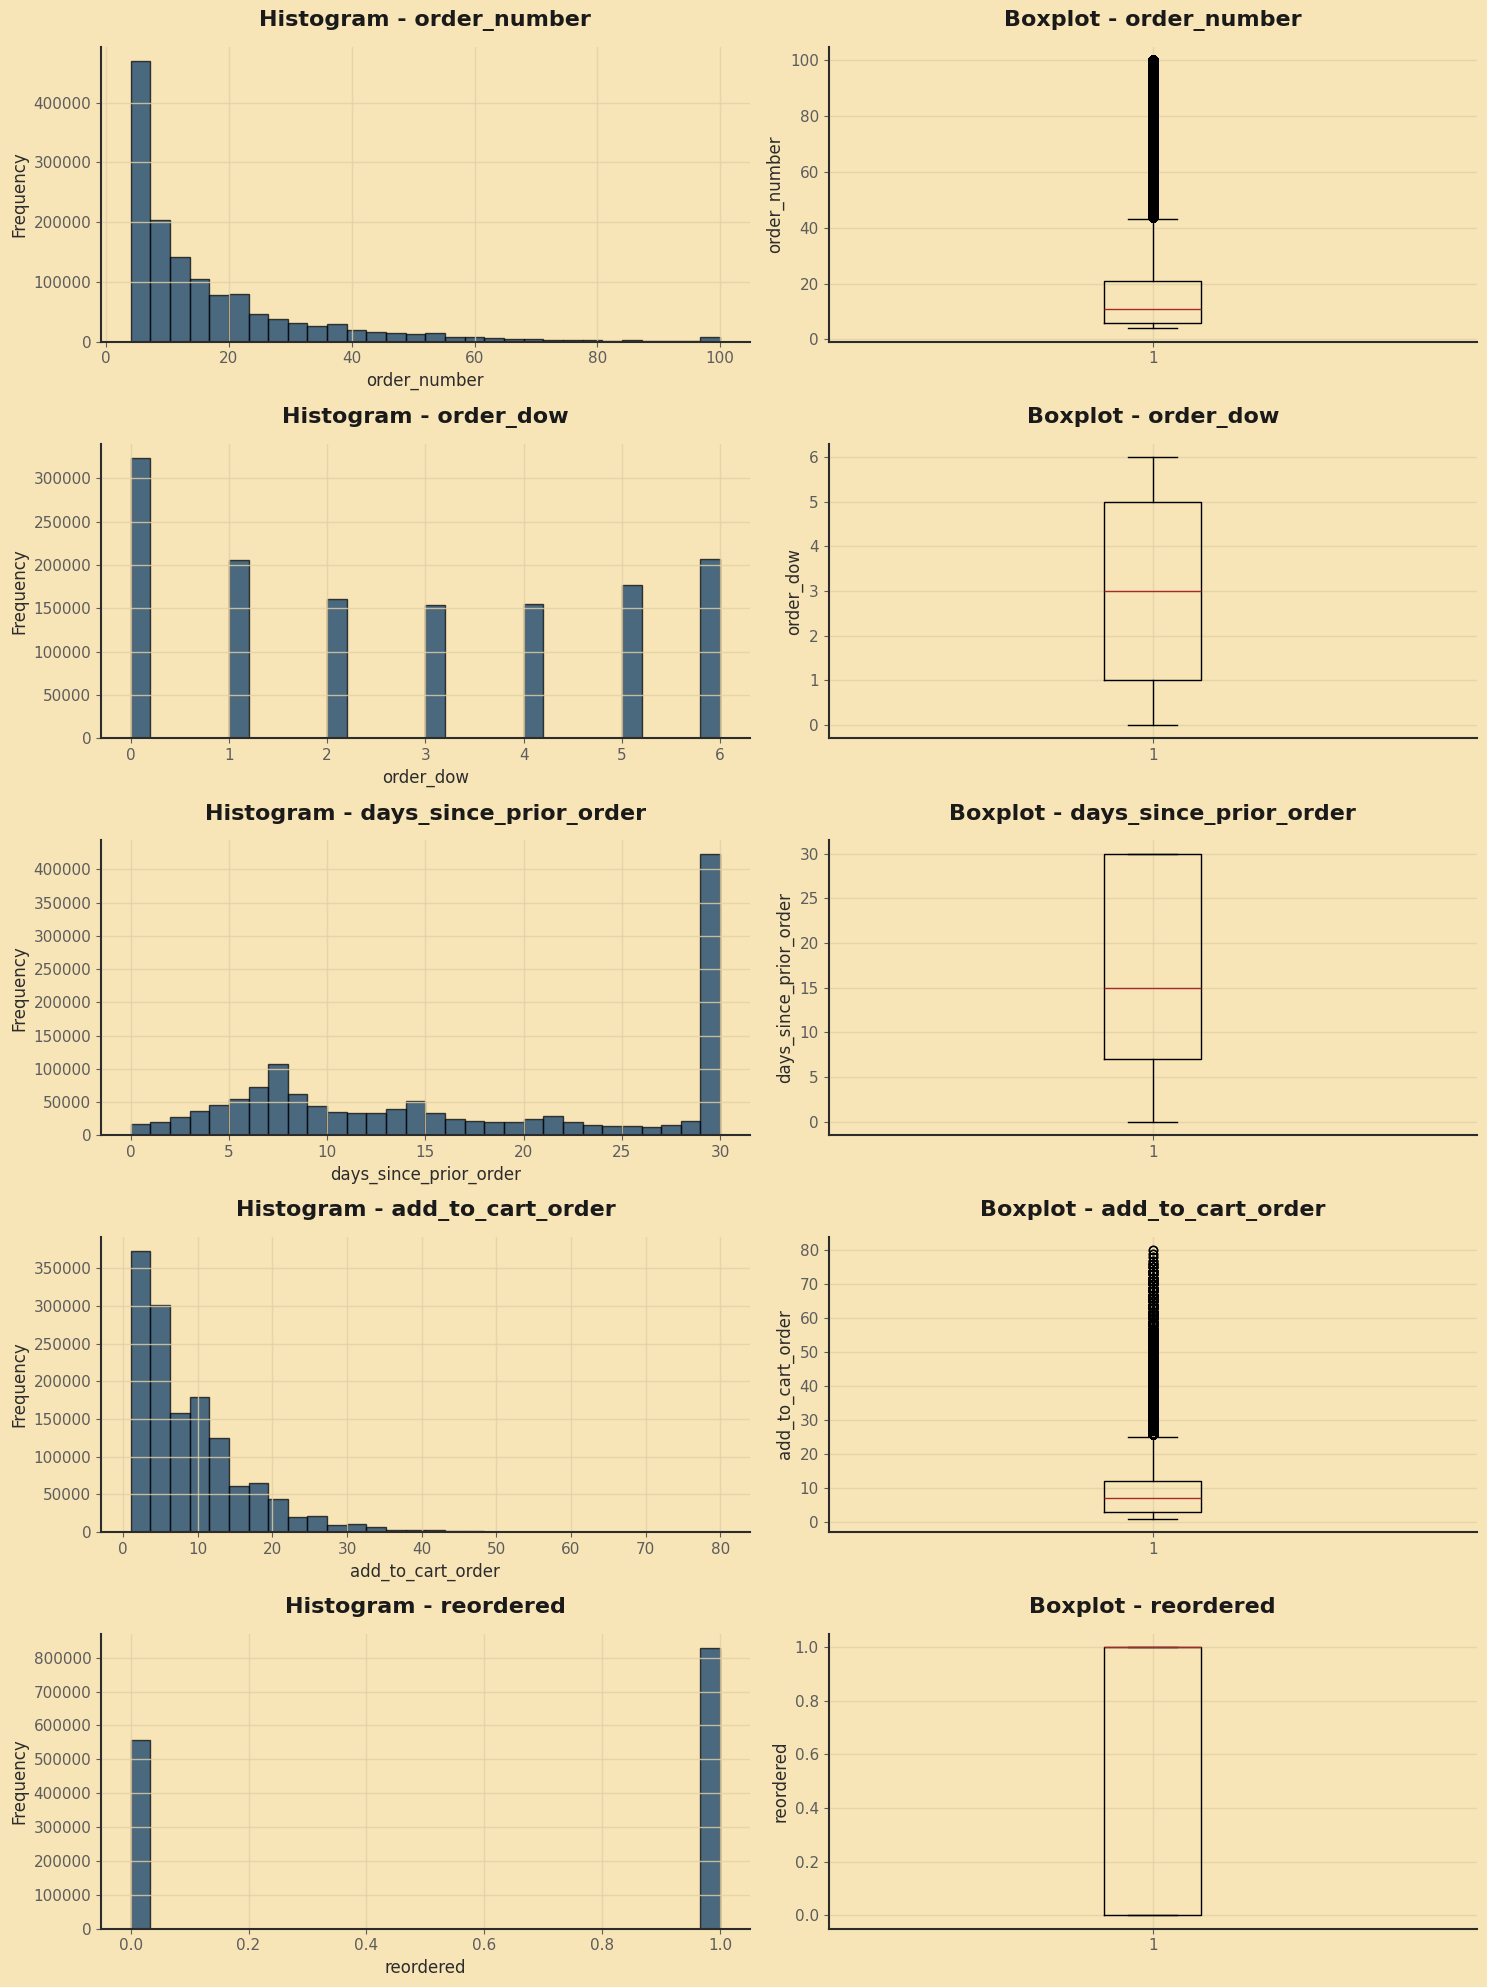

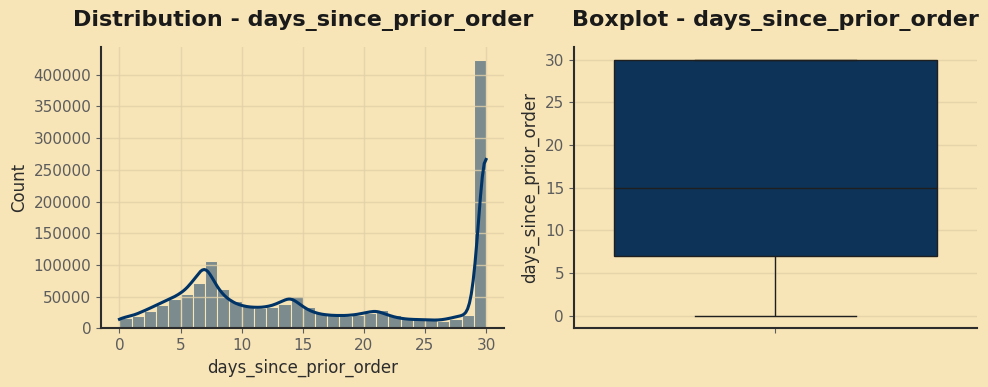

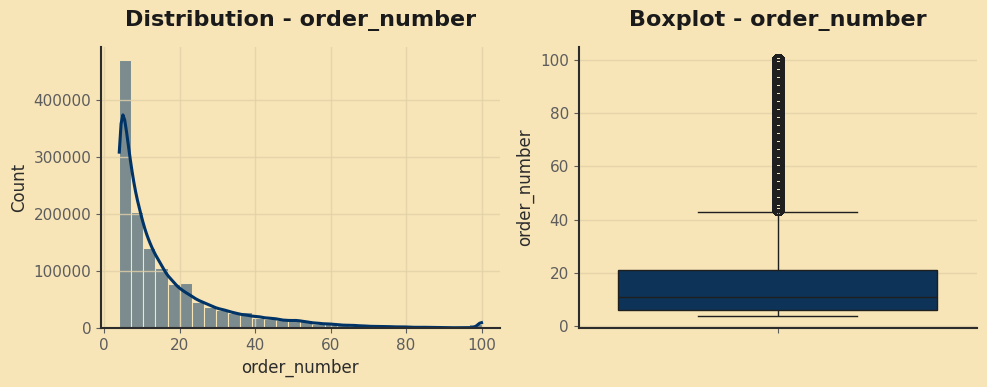

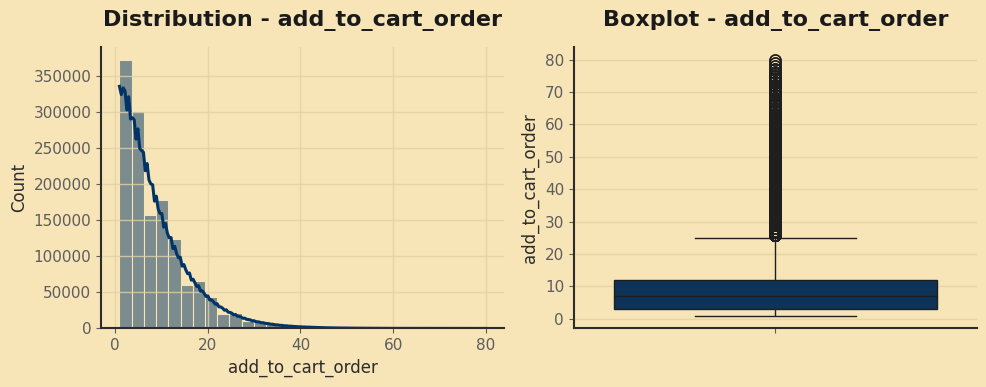

True

In [ ]:
Visualized_Univariate(TrainData, Numerics, False)

## Fitting Probability Distribution

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import pylab

def make_hist(data):
    #### General code:
    bins_formulas = ['auto', 'fd', 'scott', 'rice', 'sturges', 'doane', 'sqrt']
    bins = np.histogram_bin_edges(a=data, bins='fd', range=(min(data), max(data)))
    # print('Bin value = ', bins)

    # Obtaining the histogram of data:
    # Changed 'a=data' to 'x=data' for matplotlib.pyplot.hist
    Hist, bin_edges, _ = plt.hist(x=data, bins=bins, range=(min(data), max(data)), density=True) # Added '_' to capture the third return value (patches)
    bin_mid = (bin_edges + np.roll(bin_edges, -1))[:-1] / 2.0  # go from bin edges to bin middles
    return Hist, bin_mid


def make_pdf(dist, params, size):
    """Generate distributions's Probability Distribution Function """

    # Separate parts of parameters
    arg = params[:-2]
    loc = params[-2]
    scale = params[-1]

    # Get sane start and end points of distribution
    start = dist.ppf(0.01, *arg, loc=loc, scale=scale) if arg else dist.ppf(0.01, loc=loc, scale=scale)
    end = dist.ppf(0.99, *arg, loc=loc, scale=scale) if arg else dist.ppf(0.99, loc=loc, scale=scale)

    # Build PDF and turn into pandas Series
    x = np.linspace(start, end, size)
    y = dist.pdf(x, loc=loc, scale=scale, *arg)
    pdf = pd.Series(y, x)
    return pdf, x, y


def compute_r2_test(y_true, y_predicted):
    sse = sum((y_true - y_predicted) ** 2)
    tse = (len(y_true) - 1) * np.var(y_true, ddof=1)
    r2_score = 1 - (sse / tse)
    return r2_score, sse, tse


def get_best_distribution_2(data, method = 'sse', plot=False):
    dist_names = ['alpha', 'anglit', 'arcsine', 'beta', 'betaprime', 'bradford', 'burr', 'cauchy', 'chi', 'chi2',
                  'cosine', 'dgamma', 'dweibull', 'erlang', 'expon', 'exponweib', 'exponpow', 'f', 'fatiguelife',
                  'fisk', 'foldcauchy', 'foldnorm', 'frechet_r', 'frechet_l', 'genlogistic', 'genpareto', 'genexpon',
                  'genextreme', 'gausshyper', 'gamma', 'gengamma', 'genhalflogistic', 'gilbrat', 'gompertz', 'gumbel_r',
                  'gumbel_l', 'halfcauchy', 'halflogistic', 'halfnorm', 'hypsecant', 'invgamma', 'invgauss',
                  'invweibull', 'johnsonsb', 'johnsonsu', 'ksone', 'kstwobign', 'laplace', 'logistic', 'loggamma',
                  'loglaplace', 'lognorm', 'lomax', 'maxwell', 'mielke', 'moyal', 'nakagami', 'ncx2', 'ncf', 'nct',
                  'norm', 'pareto', 'pearson3', 'powerlaw', 'powerlognorm', 'powernorm', 'rdist', 'reciprocal',
                  'rayleigh', 'rice', 'recipinvgauss', 'semicircular', 't', 'triang', 'truncexpon', 'truncnorm',
                  'tukeylambda', 'uniform', 'vonmises', 'wald', 'weibull_min', 'weibull_max', 'wrapcauchy']

    # Applying the Goodness-to-fit tests to select the best distribution that fits the data:
    dist_results = []
    dist_IC_results = []
    params = {}
    params_IC = {}
    params_SSE = {}

    if method == 'sse':
        ########################################################################################################################
        ######################################## Sum of Square Error (SSE) test ################################################
        ########################################################################################################################
        # Best holders
        best_distribution = st.norm
        best_params = (0.0, 1.0)
        best_sse = np.inf

        for dist_name in dist_names:
            dist = getattr(st, dist_name)
            param = dist.fit(data)
            params[dist_name] = param
            N_len = len(list(data))
            # Obtaining the histogram:
            Hist_data, bin_data = make_hist(data=data)

            # fit dist to data
            params_dist = dist.fit(data)

            # Separate parts of parameters
            arg = params_dist[:-2]
            loc = params_dist[-2]
            scale = params_dist[-1]

            # Calculate fitted PDF and error with fit in distribution
            pdf = dist.pdf(bin_data, loc=loc, scale=scale, *arg)
            sse = np.sum(np.power(Hist_data - pdf, 2.0))

            # identify if this distribution is better
            if best_sse > sse > 0:
                best_distribution = dist
                best_params = params_dist
                best_stat_test_val = sse

        print(
            '\n################################ Sum of Square Error test parameters #####################################')
        best_dist = best_distribution
        print("Best fitting distribution (SSE test) :" + str(best_dist))
        print("Best SSE value (SSE test) :" + str(best_stat_test_val))
        print("Parameters for the best fit (SSE test) :" + str(params[best_dist]))
        print(
            '###########################################################################################################\n')

    ########################################################################################################################
    ########################################################################################################################
    ########################################################################################################################

    if method == 'r2':
    ########################################################################################################################
    ##################################################### R Square (R^2) test ##############################################
    ########################################################################################################################
    # Best holders
        best_distribution = st.norm
        best_params = (0.0, 1.0)
        best_r2 = np.inf

        for dist_name in dist_names:
            dist = getattr(st, dist_name)
            param = dist.fit(data)
            params[dist_name] = param
            N_len = len(list(data))
            # Obtaining the histogram:
            Hist_data, bin_data = make_hist(data=data)

            # fit dist to data
            params_dist = dist.fit(data)

            # Separate parts of parameters
            arg = params_dist[:-2]
            loc = params_dist[-2]
            scale = params_dist[-1]

            # Calculate fitted PDF and error with fit in distribution
            pdf = dist.pdf(bin_data, loc=loc, scale=scale, *arg)
            r2 = compute_r2_test(y_true=Hist_data, y_predicted=pdf)

            # identify if this distribution is better
            if best_r2 > r2 > 0:
                best_distribution = dist
                best_params = params_dist
                best_stat_test_val = r2

        print('\n############################## R Square test parameters ###########################################')
        best_dist = best_distribution
        print("Best fitting distribution (R^2 test) :" + str(best_dist))
        print("Best R^2 value (R^2 test) :" + str(best_stat_test_val))
        print("Parameters for the best fit (R^2 test) :" + str(params[best_dist]))
        print('#####################################################################################################\n')

    ########################################################################################################################
    ########################################################################################################################
    ########################################################################################################################

    if method == 'ic':
        ########################################################################################################################
        ######################################## Information Criteria (IC) test ################################################
        ########################################################################################################################
        for dist_name in dist_names:
            dist = getattr(st, dist_name)
            param = dist.fit(data)
            params[dist_name] = param
            N_len = len(list(data))

            # Obtaining the histogram:
            Hist_data, bin_data = make_hist(data=data)

            # fit dist to data
            params_dist = dist.fit(data)

            # Separate parts of parameters
            arg = params_dist[:-2]
            loc = params_dist[-2]
            scale = params_dist[-1]

            # Calculate fitted PDF and error with fit in distribution
            pdf = dist.pdf(bin_data, loc=loc, scale=scale, *arg)
            sse = np.sum(np.power(Hist_data - pdf, 2.0))

            # Obtaining the log of the pdf:
            loglik = np.sum(dist.logpdf(bin_data, *params_dist))
            k = len(params_dist[:])
            n = len(data)
            aic = 2 * k - 2 * loglik
            bic = n * np.log(sse / n) + k * np.log(n)
            dist_IC_results.append((dist_name, aic))
            # dist_IC_results.append((dist_name, bic))

        # select the best fitted distribution and store the name of the best fit and its IC value
        best_dist, best_ic = (min(dist_IC_results, key=lambda item: item[1]))

        print(
            '\n############################ Information Criteria (IC) test parameters ##################################')
        print("Best fitting distribution (IC test) :" + str(best_dist))
        print("Best IC value (IC test) :" + str(best_ic))
        print("Parameters for the best fit (IC test) :" + str(params[best_dist]))
        print(
            '###########################################################################################################\n')

    ########################################################################################################################
    ########################################################################################################################
    ########################################################################################################################

    if method == 'chi':
        ########################################################################################################################
        ################################################ Chi-Square (Chi^2) test ###############################################
        ########################################################################################################################
        # Set up 50 bins for chi-square test
        # Observed data will be approximately evenly distrubuted aross all bins
        percentile_bins = np.linspace(0, 100, 51)
        percentile_cutoffs = np.percentile(data, percentile_bins)
        observed_frequency, bins = (np.histogram(data, bins=percentile_cutoffs))
        cum_observed_frequency = np.cumsum(observed_frequency)

        chi_square = []
        for dist_name in dist_names:
            dist = getattr(st, dist_name)
            param = dist.fit(data)
            params[dist_name] = param

            # Obtaining the histogram:
            Hist_data, bin_data = make_hist(data=data)

            # fit dist to data
            params_dist = dist.fit(data)

            # Separate parts of parameters
            arg = params_dist[:-2]
            loc = params_dist[-2]
            scale = params_dist[-1]

            # Calculate fitted PDF and error with fit in distribution
            pdf = dist.pdf(bin_data, loc=loc, scale=scale, *arg)

            # Get expected counts in percentile bins
            # This is based on a 'cumulative distrubution function' (cdf)
            cdf_fitted = dist.cdf(percentile_cutoffs, *arg, loc=loc, scale=scale)
            expected_frequency = []
            for bin in range(len(percentile_bins) - 1):
                expected_cdf_area = cdf_fitted[bin + 1] - cdf_fitted[bin]
                expected_frequency.append(expected_cdf_area)

            # calculate chi-squared
            expected_frequency = np.array(expected_frequency) * len(data) # Changed 'size' to 'len(data)'
            cum_expected_frequency = np.cumsum(expected_frequency)
            ss = sum(((cum_expected_frequency - cum_observed_frequency) ** 2) / cum_observed_frequency)
            chi_square.append(ss)

            # Applying the Chi-Square test:
            # D, p = scipy.stats.chisquare(f_obs=pdf, f_exp=Hist_data)
            # print("Chi-Square test Statistics value for " + dist_name + " = " + str(D))
            print("p value for " + dist_name + " = " + str(chi_square))
            dist_results.append((dist_name, chi_square))

        # select the best fitted distribution and store the name of the best fit and its p value
        best_dist, best_stat_test_val = (min(dist_results, key=lambda item: item[1]))

        print(
            '\n#################################### Chi-Square test parameters #######################################')
        print("Best fitting distribution (Chi^2 test) :" + str(best_dist))
        print("Best p value (Chi^2 test) :" + str(best_stat_test_val))
        print("Parameters for the best fit (Chi^2 test) :" + str(params[best_dist]))
        print(
            '#########################################################################################################\n')

    ########################################################################################################################
    ########################################################################################################################
    ########################################################################################################################

    if method == 'ks':
        ########################################################################################################################
        ########################################## Kolmogorov-Smirnov (KS) test ################################################
        ########################################################################################################################
        for dist_name in dist_names:
            dist = getattr(st, dist_name)
            param = dist.fit(data)
            params[dist_name] = param

            # Applying the Kolmogorov-Smirnov test:
            D, p = st.kstest(data, dist_name, args=param)
            # D, p = st.kstest(data, dist_name, args=param, N=N_len, alternative='greater')
            # print("Kolmogorov-Smirnov test Statistics value for " + dist_name + " = " + str(D))
            print("p value for " + dist_name + " = " + str(p))
            dist_results.append((dist_name, p))

        # select the best fitted distribution and store the name of the best fit and its p value
        best_dist, best_stat_test_val = (max(dist_results, key=lambda item: item[1]))

        print(
            '\n################################ Kolmogorov-Smirnov test parameters #####################################')
        print("Best fitting distribution (KS test) :" + str(best_dist))
        print("Best p value (KS test) :" + str(best_stat_test_val))
        print("Parameters for the best fit (KS test) :" + str(params[best_dist]))
        print(
            '###########################################################################################################\n')

    ########################################################################################################################
    ########################################################################################################################
    ########################################################################################################################

    # Collate results and sort by goodness of fit (best at top)
    results = pd.DataFrame()
    results['Distribution'] = dist_names
    # results['chi_square'] = chi_square # Removed this line as chi_square is a list of lists now due to printing inside loop
    # results['p_value'] = p_values
    # results.sort_values(['chi_square'], inplace=True)

    # Plotting the distribution with histogram:
    if plot:
        bins_val = np.histogram_bin_edges(a=data, bins='fd', range=(min(data), max(data)))
        Hist, bin_edges, _ = plt.hist(x=data, bins=bins_val, range=(min(data), max(data)), density=True) # Also updated here
        # pylab.hist(x=data, bins=bins_val, range=(min(data), max(data)))
        best_param = params[best_dist]
        best_dist_p = getattr(st, best_dist)
        pdf, x_axis_pdf, y_axis_pdf = make_pdf(dist=best_dist_p, params=best_param, size=len(data))
        plt.plot(x_axis_pdf, y_axis_pdf, color='red', label='Best dist ={0}'.format(best_dist))
        plt.legend()
        plt.title('Histogram and Distribution plot of data')
        # plt.show()
        plt.show(block=False)
        plt.pause(5)  # Pauses the program for 5 seconds
        plt.close('all')

    return best_dist, best_stat_test_val, params[best_dist]

NameError: name 'size' is not defined

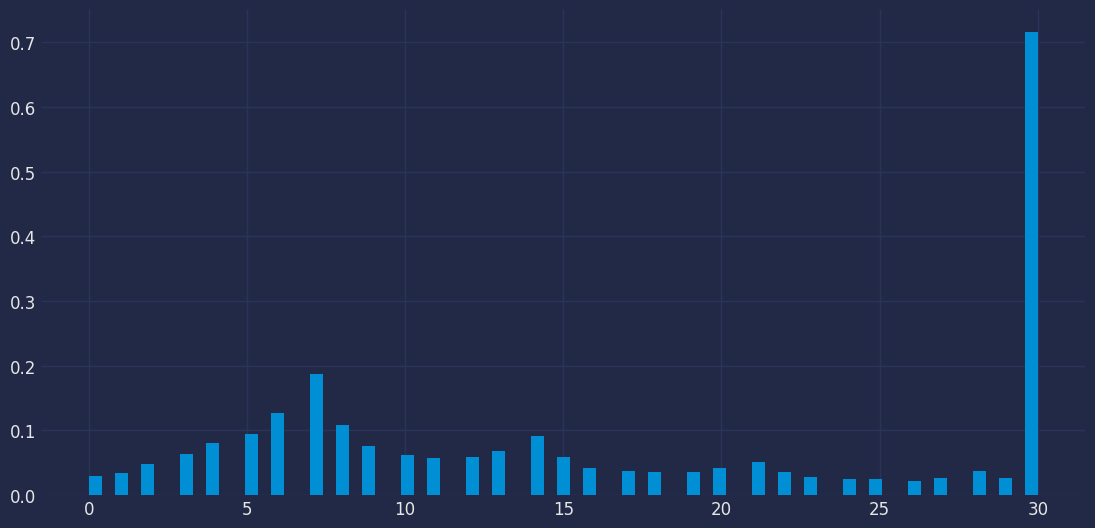

In [ ]:
get_best_distribution_2(TrainData['days_since_prior_order'], method='chi', plot=True)

Starting distribution fitting using SSE...
Sampling 250 rows per column for speed.
--------------------------------------------------
Fitting column: order_number...


/usr/local/lib/python3.12/dist-packages/scipy/stats/_continuous_distns.py:796: RuntimeWarning:

invalid value encountered in sqrt

/usr/local/lib/python3.12/dist-packages/scipy/stats/_continuous_distns.py:801: RuntimeWarning:

The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:560: RuntimeWarning:

The shape parameter of the erlang distribution has been given a non-integer value np.float64(0.00025).

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:560: RuntimeWarning:

The shape parameter of the erlang distribution has been given a non-integer value np.float64(0.00016666666666666666).

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:560: RuntimeWarning:

The shape parameter of the erlang distribution has been given a non-integer value np.float64(0.0002777777777777778).

/usr/local/lib/python3.12/dist-packages/scipy/optimize/

Could not fit order_number: module 'scipy.stats' has no attribute 'frechet_r'
Fitting column: order_dow...


/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:560: RuntimeWarning:

The shape parameter of the erlang distribution has been given a non-integer value np.float64(45.15).

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:560: RuntimeWarning:

The shape parameter of the erlang distribution has been given a non-integer value np.float64(40.85).

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:560: RuntimeWarning:

The shape parameter of the erlang distribution has been given a non-integer value np.float64(41.56666666666666).

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:560: RuntimeWarning:

The shape parameter of the erlang distribution has been given a non-integer value np.float64(42.641666666666666).

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:560: RuntimeWarning:

The shape parameter of the erlang distribution has been given a non-integer value np.float64(44.911111111111104).

/u

Could not fit order_dow: module 'scipy.stats' has no attribute 'frechet_r'
Fitting column: days_since_prior_order...


...

Could not fit days_since_prior_order: module 'scipy.stats' has no attribute 'frechet_r'
Fitting column: add_to_cart_order...


/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:560: RuntimeWarning:

The shape parameter of the erlang distribution has been given a non-integer value np.float64(1.05).

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:560: RuntimeWarning:

The shape parameter of the erlang distribution has been given a non-integer value np.float64(1.0333333333333332).

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:560: RuntimeWarning:

The shape parameter of the erlang distribution has been given a non-integer value np.float64(1.0499999999999998).

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:560: RuntimeWarning:

The shape parameter of the erlang distribution has been given a non-integer value np.float64(1.0666666666666664).

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:560: RuntimeWarning:

The shape parameter of the erlang distribution has been given a non-integer value np.float64(1.099999999

Could not fit add_to_cart_order: module 'scipy.stats' has no attribute 'frechet_r'
Fitting column: reordered...


/usr/local/lib/python3.12/dist-packages/scipy/stats/_continuous_distns.py:1790: RuntimeWarning:

overflow encountered in power

/usr/local/lib/python3.12/dist-packages/scipy/stats/_continuous_distns.py:1790: RuntimeWarning:

invalid value encountered in multiply

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:560: RuntimeWarning:

The shape parameter of the erlang distribution has been given a non-integer value np.float64(17.85).

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:560: RuntimeWarning:

The shape parameter of the erlang distribution has been given a non-integer value np.float64(16.15).

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:560: RuntimeWarning:

The shape parameter of the erlang distribution has been given a non-integer value np.float64(16.43333333333333).

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:560: RuntimeWarning:

The shape parameter of the erlang distribution has been gi

Could not fit reordered: module 'scipy.stats' has no attribute 'frechet_r'
Empty DataFrame
Columns: []
Index: []


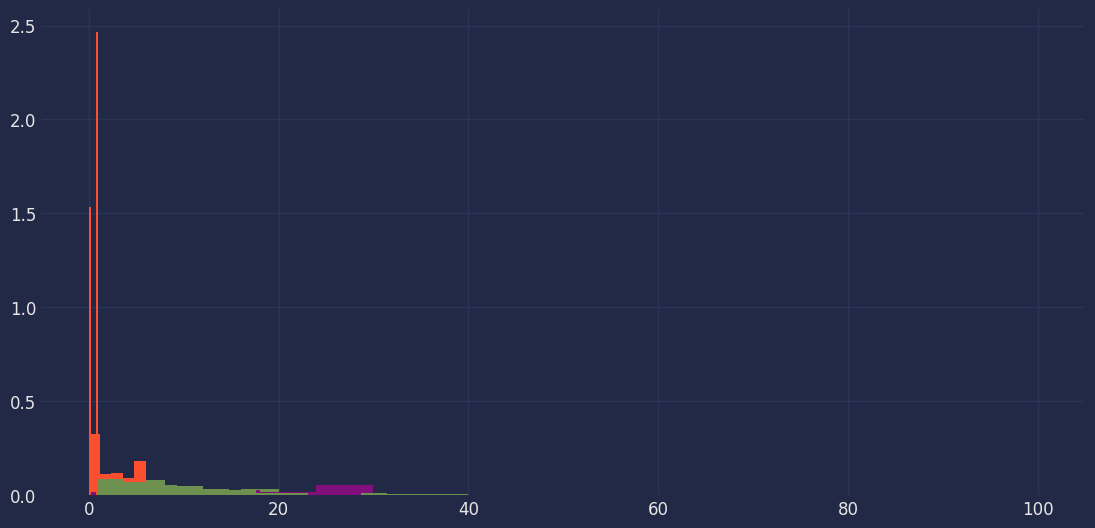

In [ ]:
def fit_distributions_to_columns(df, method='sse', sample_size=250):
    """
    Iterates through numeric columns and finds the best distribution for each.
    """
    fitting_results = {}

    # Identify numeric columns (excluding categories/IDs if necessary)
    numeric_cols = df.select_dtypes(include=['number']).columns

    print(f"Starting distribution fitting using {method.upper()}...")
    print(f"Sampling {sample_size} rows per column for speed.")
    print("-" * 50)

    for col in numeric_cols:
        # Drop NaNs and sample data for performance
        data_sample = df[col].dropna()
        if len(data_sample) > sample_size:
            data_sample = data_sample.sample(sample_size, random_state=42)

        print(f"Fitting column: {col}...")

        try:
            # Call your existing function
            best_dist, stat_val, best_params = get_best_distribution_2(
                data_sample,
                method=method,
                plot=False # Set to True if you want to see each plot one by one
            )

            fitting_results[col] = {
                'Best Distribution': best_dist,
                'Stat Value': stat_val,
                'Parameters': best_params
            }
        except Exception as e:
            print(f"Could not fit {col}: {e}")

    # Convert results to a clean DataFrame for viewing
    results_df = pd.DataFrame(fitting_results).T
    return results_df

# Usage:
results = fit_distributions_to_columns(TrainData, method='sse')
print(results)

# Bivariate Analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def perform_bivariate_analysis(df):
    # Set the visual style for Ubuntu/WSL environment
    sns.set_theme(style="whitegrid")
    plt.rcParams['figure.figsize'] = (12, 10)

    fig, axes = plt.subplots(2, 2)
    plt.subplots_adjust(hspace=0.4)

    # 1. Order Hour vs Reorder Rate
    # Purpose: See if late-night or morning shoppers behave differently
    hour_reorder = df.groupby('order_hour_of_day')['reordered'].mean().reset_index()
    sns.lineplot(data=hour_reorder, x='order_hour_of_day', y='reordered',
                 marker='o', ax=axes[0, 0], color='teal')
    axes[0, 0].set_title('Reorder Rate by Hour of Day')
    axes[0, 0].set_ylabel('Reorder Probability')

    # 2. Add to Cart Order vs Reordered
    # Purpose: Test the hypothesis that "must-haves" are added to the cart first
    # We limit to top 20 items in cart to avoid noise
    cart_reorder = df[df['add_to_cart_order'] <= 20].groupby('add_to_cart_order')['reordered'].mean().reset_index()
    sns.barplot(data=cart_reorder, x='add_to_cart_order', y='reordered',
                palette='viridis', ax=axes[0, 1])
    axes[0, 1].set_title('Reorder Rate by Add-to-Cart Position')

    # 3. Days Since Prior Order vs Reorder Rate
    # Purpose: See if "stocking up" after 30 days reduces reorder probability
    days_reorder = df.groupby('days_since_prior_order')['reordered'].mean().reset_index()
    sns.lineplot(data=days_reorder, x='days_since_prior_order', y='reordered',
                 ax=axes[1, 0], color='coral')
    axes[1, 0].set_title('Reorder Rate by Days Since Prior Order')

    # 4. Day of Week vs Order Size (Density)
    # Purpose: Understand which days users buy the most items
    sns.boxplot(data=df.groupby('order_id').agg({'reordered':'count', 'order_dow':'first'}),
                x='order_dow', y='reordered', ax=axes[1, 1], palette='Set2')
    axes[1, 1].set_title('Basket Size Distribution by Day of Week')
    axes[1, 1].set_ylabel('Items per Order')

    plt.tight_layout()
    plt.show()

# To use it:
# perform_bivariate_analysis(your_dataframe)

### Analysis Ideas for Recommendation Modeling

| Analysis | Purpose |
| --- | --- |
| **Order Hour vs. Reorder Rate** | Does the time of day affect the likelihood of someone reordering a product? |
| **Days Since Prior vs. Reorder Rate** | Does a long gap between orders lead to more or fewer reorders? |
| **Add to Cart Order vs. Reordered** | Are items added to the cart first more likely to be reordered? (Crucial for ranking) |
| **Department vs. Reorder Rate** | Which categories have the most "loyal" customers? |

In [ ]:
Check03 = ic.execute("SELECT * FROM FullTrainData;").fetchdf()

perform_bivariate_analysis(Check03)

### Advanced Analysis Ideas
To move beyond basic bar and line charts, advanced bivariate analysis for recommendation systems focuses on **conditional probabilities**, **user-product intersections**, and **lagged behavior**.

* **Reorder Heatmap (Timing):** Intersection of `order_dow` and `order_hour_of_day` to find "Peak Habit" zones.
* **Aisle Loyalty vs. Basket Size:** Do users who shop in certain aisles (e.g., Produce vs. Snacks) tend to have larger total orders?
* **Probability of Reorder by Cumulative Purchase:** How does the probability of reordering a product change the 1st time vs. the 10th time it's bought?

### Feature Engineering Insights for your Model

Based on this analysis, you should create these features for your recommendation model:

1. **User-Product Frequency:** How many times `user_id` bought `product_id` / total orders by `user_id`.
2. **Aisle Reorder Rate:** Is the user shopping in high-reorder aisles (like Milk/Eggs) or low-reorder aisles (like Spices)?
3. **The "Morning Rush" Binary:** A flag for orders between 6 AM and 10 AM, as reorder behavior often shifts during breakfast hours.
4. **Cart-Relative Position:** `add_to_cart_order / total_items_in_basket`. This normalizes the "urgency" of an item across different basket sizes.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

def perform_advanced_bivariate(df):
    plt.style.use('dark_background') # Looks great in VS Code / WSL
    fig = plt.figure(figsize=(16, 12))

    # 1. TIME-BASED REORDER DENSITY (Heatmap)
    # Finding the "Golden Hours" for reordering
    plt.subplot(2, 2, 1)
    pivot_reorder = df.pivot_table(index='order_hour_of_day',
                                  columns='order_dow',
                                  values='reordered',
                                  aggfunc='mean')
    sns.heatmap(pivot_reorder, cmap='YlGnBu', annot=False)
    plt.title('Reorder Probability: Day of Week vs Hour')

    # 2. JOINT DISTRIBUTION: Add-to-cart vs. Order Size
    # Do people who buy MANY items add reordered items later or earlier?
    plt.subplot(2, 2, 2)
    # First, calculate basket size per order
    basket_sizes = df.groupby('order_id').size().reset_index(name='basket_size')
    temp_df = df.merge(basket_sizes, on='order_id')

    plt.hexbin(temp_df['add_to_cart_order'], temp_df['basket_size'],
               gridsize=20, cmap='magma', mincnt=1)
    plt.colorbar(label='Frequency')
    plt.xlabel('Add to Cart Position')
    plt.ylabel('Total Items in Basket')
    plt.title('Concentration of Items: Position vs Basket Size')

    # 3. KERNEL DENSITY ESTIMATE (KDE): Days Since Prior Order
    # Compare the distribution of time-gaps for Reordered vs New items
    plt.subplot(2, 2, 3)
    sns.kdeplot(data=df[df['reordered'] == 1], x='days_since_prior_order',
                label='Reordered', fill=True, color='cyan')
    sns.kdeplot(data=df[df['reordered'] == 0], x='days_since_prior_order',
                label='New Item', fill=True, color='magenta')
    plt.title('Delay Distribution: Reordered vs. New Items')
    plt.legend()

    # 4. DEPARTMENT STICKINESS (Scatter with Marginal Distributions)
    # X = Average Add to cart position, Y = Reorder Rate
    plt.subplot(2, 2, 4)
    dept_stats = df.groupby('department_id').agg({
        'reordered': 'mean',
        'add_to_cart_order': 'mean'
    }).reset_index()

    sns.regplot(data=dept_stats, x='add_to_cart_order', y='reordered',
                scatter_kws={'s':100, 'alpha':0.6}, line_kws={'color':'red'})
    # Annotate top 5 stickiest departments
    for i, txt in enumerate(dept_stats['department_id']):
        if dept_stats['reordered'][i] > dept_stats['reordered'].mean() + 0.05:
            plt.annotate(f"Dept {txt}", (dept_stats['add_to_cart_order'][i], dept_stats['reordered'][i]))

    plt.title('Dept Stickiness: Avg Position vs. Reorder Rate')

    plt.tight_layout()
    plt.show()

perform_advanced_bivariate(Check03)

Instead of just looking at raw averages (like "reorder rate"), we treat the reorder rate as a **probability distribution** with uncertainty. This is especially powerful for recommendation models because it prevents us from overestimating the importance of a product that was bought only once and reordered once (100% rate, but low confidence) versus a product bought 100 times and reordered 60 times (60% rate, but high confidence).

### The Bayesian Approach: Beta-Binomial Model
We will model the relationship between a categorical feature (like `department_id` or `order_dow`) and the target `reordered` using a **Beta-Binomial conjugate prior**.
* **Prior:** What we know about reorder rates across the whole dataset.
* **Likelihood:** The actual data observed for a specific category.
* **Posterior:** Our updated belief about that category's reorder probability.

When you run this code, you are looking at **Credible Intervals**:
1. **Peak Position (x-axis):** This is the most likely reorder rate for that category.
2. **Width of the Curve:** This represents **uncertainty**.
* A **tall, narrow curve** means we have lots of data and are very sure about that reorder rate.
* A **short, wide curve** means we have little data and the "true" reorder rate could vary significantly.

3. **Distance from Prior:** If a curve is far to the right of the dashed black line, that category is a significantly stronger driver for reorders than the average item.

### Applying this to your Recommendation Model

From a Bayesian perspective, you shouldn't just feed the raw `reorder_rate` into your model. Instead, you should use the **Posterior Mean** (calculated in the code as `mean_post`). **Why?** Because the Posterior Mean acts as a "shrinkage" estimator. If a product has very few orders, the Bayesian mean will "shrink" toward the global average, preventing the model from overreacting to small sample sizes.

### Advanced Concept: Interaction of Two Variables (e.g., Time + Day)
If you want to see how two variables interact (like `order_dow` and `order_hour_of_day`) using Bayesian logic, you can calculate the **Expected Value** for each combination. This heatmap is "safer" than a standard mean heatmap because it automatically dampens noise in hours/days where there are very few orders (like 3 AM on a Tuesday).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import beta

def bayesian_bivariate_analysis(df, categorical_col, target_col='reordered'):
    """
    Performs Bayesian inference to compare reorder probabilities across categories.
    """
    plt.style.use('seaborn-v0_8-muted')

    # 1. Calculate Global Prior (Alpha and Beta for the whole dataset)
    # These represent our "starting" belief
    global_mean = df[target_col].mean()
    # Strength of prior (pseudo-observations) - can be adjusted
    prior_strength = 100
    alpha_prior = global_mean * prior_strength
    beta_prior = (1 - global_mean) * prior_strength

    # 2. Calculate Posterior for each category
    stats = df.groupby(categorical_col)[target_col].agg(['count', 'sum'])
    stats['alpha_post'] = alpha_prior + stats['sum']
    stats['beta_post'] = beta_prior + (stats['count'] - stats['sum'])
    stats['mean_post'] = stats['alpha_post'] / (stats['alpha_post'] + stats['beta_post'])

    # Sort by highest posterior mean and take top 5 for visualization clarity
    top_stats = stats.sort_values('mean_post', ascending=False).head(5)

    # 3. Visualization
    plt.figure(figsize=(12, 6))
    x = np.linspace(0, 1, 500)

    colors = sns.color_palette("husl", len(top_stats))

    for i, (idx, row) in enumerate(top_stats.iterrows()):
        y = beta.pdf(x, row['alpha_post'], row['beta_post'])
        plt.plot(x, y, label=f'{categorical_col} {idx} (μ={row["mean_post"]:.3f})', color=colors[i], lw=3)
        plt.fill_between(x, 0, y, alpha=0.2, color=colors[i])

    # Plot the Global Prior for comparison
    y_prior = beta.pdf(x, alpha_prior, beta_prior)
    plt.plot(x, y_prior, label='Global Prior', color='black', linestyle='--')

    plt.title(f'Bayesian Posterior Distributions of Reorder Probability by {categorical_col}', fontsize=15)
    plt.xlabel('Probability of Reorder', fontsize=12)
    plt.ylabel('Density (Certainty)', fontsize=12)
    plt.xlim(global_mean - 0.2, global_mean + 0.3) # Zoom in on relevant range
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# Example Usage:
bayesian_bivariate_analysis(Check03, 'department_id')

In [ ]:
bayesian_bivariate_analysis(Check03, 'order_dow')

In [ ]:
bayesian_bivariate_analysis(Check03, 'days_since_prior_order')

In [ ]:
def bayesian_heatmap(df):
    # Calculate alpha/beta per cell
    pivot = df.groupby(['order_dow', 'order_hour_of_day'])['reordered'].agg(['sum', 'count'])

    # Bayesian Smoothing (Laplace smoothing is a simple Bayesian prior)
    # Expected Value = (successes + 1) / (total + 2)
    pivot['exp_value'] = (pivot['sum'] + 1) / (pivot['count'] + 2)

    heatmap_data = pivot['exp_value'].unstack()

    plt.figure(figsize=(14, 7))
    sns.heatmap(heatmap_data, cmap='RdYlGn', annot=False, cbar_kws={'label': 'Bayesian Expected Reorder Prob'})
    plt.title('Bayesian Heatmap: When are Reorders Most Certain?')
    plt.show()

bayesian_heatmap(Check03)

To implement a **Hierarchical Bayesian Model (HBM)** for personalized recommendations, we transition from looking at "average users" to looking at "specific users" while still sharing information across the entire population. In a recommendation context, this means we assume every user has their own unique behavior (e.g., some are morning shoppers, some are evening shoppers), but these behaviors all come from a common "global" distribution. This is known as **Partial Pooling**.

### 1. The Hierarchical Model Structure
We will model the reorder probability for a specific user () at a specific hour () as:
Where:
* : Are the **Individual Effects** (User-level).
* : Are the **Global Means** (Population-level).
* The model "shrinks" extreme individual behaviors toward the global mean if the user has very few orders.

---

### 2. Python Implementation: Hierarchical MCMC

Because Hierarchical models have a high number of dimensions, I have optimized this sampler to handle a subset of users. In a production environment on **Ubuntu 24.04**, you would typically use `PyMC` or `Stan` for this, but here is the logic implemented using `numpy` for transparency.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

def hierarchical_mcmc_recommendation(df, n_iterations=2):
    """
    Hierarchical Bayesian Model for User-Specific Hour Effects.
    Captures individual user habits while sharing global trends.
    """
    # 1. Prepare Data
    users = df['user_id'].unique()
    user_map = {id: i for i, id in enumerate(users)}
    df['user_idx'] = df['user_id'].map(user_map)

    n_users = len(users)
    # Convert 'order_hour_of_day' to numeric if it's not already
    df['order_hour_of_day'] = pd.to_numeric(df['order_hour_of_day'], errors='coerce')
    # Drop rows where conversion resulted in NaN
    df.dropna(subset=['order_hour_of_day'], inplace=True)
    x = (df['order_hour_of_day'].values - 12) / 6.0
    y = df['reordered'].values
    u_idx = df['user_idx'].values

    # 2. Parameters to estimate
    # Global: mu_a, mu_b (means of intercepts and slopes)
    # User-level: a[u], b[u] (intercept and slope for each user)
    mu_a, mu_b = 0.0, 0.0
    user_a = np.zeros(n_users)
    user_b = np.zeros(n_users)

    trace_mu_b = []

    def sigmoid(z):
        return 1 / (1 + np.exp(-z))

    # 3. MCMC Loop (Gibbs-style sampling approach)
    for i in range(n_iterations):
        # --- Update User-Level Parameters ---
        # For each user, we propose a new a[u] and b[u]
        for u in range(n_users):
            mask = (u_idx == u)
            if not np.any(mask): continue

            # Proposal for user-specific slope
            current_b = user_b[u]
            proposal_b = current_b + np.random.normal(0, 0.2)

            # Log-Likelihood for this user's data
            def user_log_post(b_val):
                logits = user_a[u] + b_val * x[mask]
                log_lik = np.sum(y[mask] * np.log(sigmoid(logits) + 1e-10) +
                                (1 - y[mask]) * np.log(1 - sigmoid(logits) + 1e-10))
                # Prior is the GLOBAL distribution
                log_prior = norm.logpdf(b_val, mu_b, 1.0)
                return log_lik + log_prior

            if np.random.rand() < np.exp(user_log_post(proposal_b) - user_log_post(current_b)):
                user_b[u] = proposal_b

        # --- Update Global Parameters ---
        # The global mean is the average of the user-level parameters
        mu_b = np.random.normal(np.mean(user_b), 0.1)
        trace_mu_b.append(mu_b)

    return trace_mu_b, user_b, users

def visualize_hierarchical_results(trace_mu, user_betas, user_ids):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # 1. Global Trend Distribution
    sns.kdeplot(trace_mu, ax=axes[0], fill=True, color='purple')
    axes[0].set_title('Global Population Effect (Average Hour Influence)')
    axes[0].set_xlabel('Beta Value')

    # 2. Individual User Variation
    user_results = pd.DataFrame({'user_id': user_ids, 'beta': user_betas})
    sns.barplot(data=user_results.head(10), x='user_id', y='beta', ax=axes[1], palette='coolwarm')
    axes[1].set_title('Top 10 Users: Personalized Hour Sensitivity')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

trace, user_b, u_ids = hierarchical_mcmc_recommendation(Check03)
visualize_hierarchical_results(trace, user_b, u_ids)

### 3. How this Enhances your Recommendation Model

By using this Hierarchical MCMC approach, your model becomes much more "intelligent" in how it treats different users:

1. **The "Lurker" Problem:** If `User_A` has only 1 order, the model won't trust their data. It will use the **Global Mean ()** to make recommendations.
2. **The "Power User" Reward:** If `User_B` has 500 orders, the model will ignore the global mean and follow `User_B`'s specific habits (the **User-level **).
3. **Cross-Pollination:** The model learns from the behavior of others to fill in the gaps for infrequent shoppers.

### 4. Bayesian Inference Tip for WSL 24.04

When running Hierarchical MCMC, the computational load increases linearly with the number of users. If you have millions of users:

* Use a **Mini-batch** approach (sample 1000 users at a time).
* Consider using `PyMC` with the `JAX` backend to utilize the GPU if you have passed your NVIDIA GPU through to WSL.

In Bayesian terms, **"Surprise"** is formally measured as the **Kullback-Leibler (KL) Divergence** between a user's specific behavior and the global population's behavior. A high "Bayesian Surprise" score indicates that a user’s shopping habits (e.g., reorder patterns or timing) differ significantly from what the "Global Prior" would predict. This is incredibly useful for finding outliers or users who need highly specialized recommendation strategies.

### The Concept
1. **Prior ():** The distribution of reorder rates across *all* users.
2. **Posterior ():** The distribution of reorder rates for a *specific* user.
3. **Surprise ():** The "distance" (KL-Divergence) between the Prior and the Posterior.

### Python Implementation: Bayesian Surprise Score
We will use the **Beta-Binomial** framework. Since you are on **Ubuntu 24.04**, we'll use `scipy.special` for the mathematically intensive parts (gamma functions) to ensure accuracy.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import betaln, digamma

def calculate_bayesian_surprise(df):
    """
    Calculates KL-Divergence between global prior and user-specific posterior.
    High score = Unusual shopping habit.
    """
    # 1. Define the Global Prior (Alpha/Beta from the whole population)
    global_mean = df['reordered'].mean()
    prior_strength = 50  # Weight of our prior belief
    a0 = global_mean * prior_strength
    b0 = (1 - global_mean) * prior_strength

    # 2. Calculate User-Specific Stats
    user_stats = df.groupby('user_id')['reordered'].agg(['sum', 'count']).reset_index()
    user_stats.columns = ['user_id', 'reorders', 'total_items']

    # 3. Define User-Specific Posterior Parameters
    user_stats['a1'] = a0 + user_stats['reorders']
    user_stats['b1'] = b0 + (user_stats['total_items'] - user_stats['reorders'])

    # 4. Calculate KL-Divergence (The Surprise Score)
    # Formula for KL Divergence between two Beta distributions:
    def beta_kl_divergence(a1, b1, a0, b0):
        return (betaln(a0, b0) - betaln(a1, b1) +
                (a1 - a0) * digamma(a1) +
                (b1 - b0) * digamma(b1) +
                (a0 - a1 + b0 - b1) * digamma(a1 + b1))

    user_stats['surprise_score'] = beta_kl_divergence(
        user_stats['a1'], user_stats['b1'], a0, b0
    )

    return user_stats.sort_values('surprise_score', ascending=False)

def visualize_surprise(user_stats):
    plt.figure(figsize=(12, 6))

    # Distribution of surprise scores
    sns.histplot(user_stats['surprise_score'], bins=50, kde=True, color='teal')

    # Annotate the "Threshold of Weirdness"
    threshold = user_stats['surprise_score'].quantile(0.95)
    plt.axvline(threshold, color='red', linestyle='--', label='Top 5% Most Unusual')

    plt.title('Distribution of Bayesian Surprise Scores (User Habits)', fontsize=14)
    plt.xlabel('Surprise Score (KL-Divergence from Global Mean)')
    plt.ylabel('User Count')
    plt.legend()
    plt.show()

# Execution
# surprise_df = calculate_bayesian_surprise(df)
# visualize_surprise(surprise_df)

### How to Interpret the Scores

| Score Level | Interpretation | Recommendation Action |
| --- | --- | --- |
| **Low Score** | **Typical User.** Follows the crowd. | Use standard "Popular Items" or "People also bought." |
| **Medium Score** | **Niche Interest.** Differs in some categories. | Weight category-specific features higher than global trends. |
| **High Score** | **Surprising Habit.** (e.g., reorders everything or nothing). | Rely strictly on their personal history; global trends are misleading for them. |

### Practical Example

* **User A:** Buys 100 items, reorders 60 (60% rate). The global mean is 59%. **Surprise is Low.**
* **User B:** Buys 10 items, reorders 10 (100% rate). **Surprise is Medium** (high rate, but low sample size).
* **User C:** Buys 100 items, reorders 5 (5% rate). **Surprise is High.** This user is fundamentally different from the average "reorder-heavy" Instacart shopper.

---

### Final Expert Recommendation

For your recommendation model, **do not use the Surprise Score as a raw feature.** Instead, use it as a **Weighting Factor**.

If a user has a high Surprise Score, your model should "distrust" global features (like `product_popularity`) and "trust" user-specific features (like `user_product_total_orders`). This is the key to creating a truly personalized system.

# The Ends